Запазено успешно в: beamer/images/train_test_scores_model_complexity.png


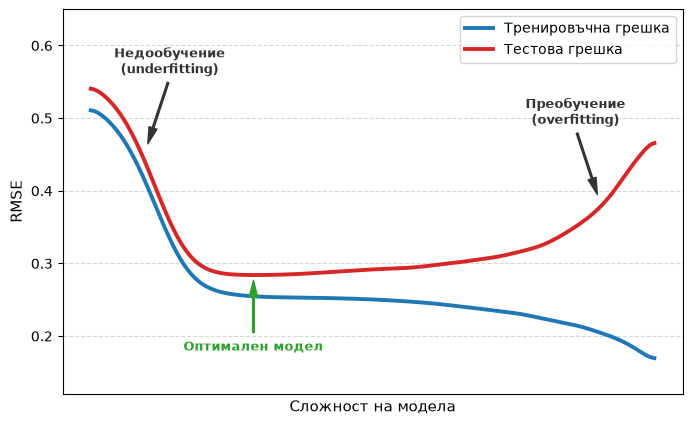

In [31]:
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error


def plot_and_save_smooth_u_shape(save_path=None):
    """Генерира перфектна, гладка U-образна крива с анотации изцяло ВЪТРЕ в графиката."""
    np.random.seed(42)

    # 1. Генериране на данни с реален шум
    N = 100
    X = np.linspace(-3, 3, N).reshape(-1, 1)
    y = np.sin(X).ravel() + np.random.normal(0, 0.3, size=N)

    # 2. Обхват за сложност (gamma)
    n_points = 240
    gammas = np.logspace(-2.5, 1.0, n_points)

    # Monte Carlo subsampling
    n_bootstrap = 30
    train_rmse_matrix = np.zeros((n_bootstrap, n_points))
    test_rmse_matrix = np.zeros((n_bootstrap, n_points))

    for b in range(n_bootstrap):
        indices = np.random.permutation(N)
        train_idx, test_idx = indices[: int(0.6 * N)], indices[int(0.6 * N) :]

        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]

        for i, gamma in enumerate(gammas):
            model = KernelRidge(kernel="rbf", gamma=gamma, alpha=1e-3)
            model.fit(X_tr, y_tr)

            train_rmse_matrix[b, i] = np.sqrt(
                mean_squared_error(y_tr, model.predict(X_tr))
            )
            test_rmse_matrix[b, i] = np.sqrt(
                mean_squared_error(y_te, model.predict(X_te))
            )

    train_rmse_mean = np.mean(train_rmse_matrix, axis=0)
    test_rmse_mean = np.mean(test_rmse_matrix, axis=0)

    train_rmse_smooth = gaussian_filter1d(train_rmse_mean, sigma=3)
    test_rmse_smooth = gaussian_filter1d(test_rmse_mean, sigma=3)

    complexity = np.linspace(0, 1, n_points)

    # 3. Изчертаване на графиката
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(
        complexity,
        train_rmse_smooth,
        color="#1f77b4",
        linewidth=2.8,
        label="Тренировъчна грешка",
    )
    ax.plot(
        complexity,
        test_rmse_smooth,
        color="#d62728",
        linewidth=2.8,
        label="Тестова грешка",
    )

    ax.set_xlabel("Сложност на модела", fontsize=11)
    ax.set_ylabel("RMSE", fontsize=11)

    # Легенда в горния десен ъгъл
    ax.legend(loc="upper right", fontsize=10, frameon=True)

    ax.set_xticks([])
    ax.grid(True, linestyle="--", alpha=0.5)

    # Фиксираме Y-границите
    ax.set_ylim(0.12, 0.65)

    # Анотация: Underfitting (скъсена стрелка)
    ax.annotate(
        "Недообучение\n(underfitting)",
        xy=(0.10, test_rmse_smooth[20]),
        xytext=(0.14, test_rmse_smooth[20] + 0.10),
        arrowprops=dict(
            facecolor="#333333",
            edgecolor="#333333",
            shrink=0.03,
            width=1.2,
            headwidth=6,
        ),
        fontsize=9.5,
        fontweight="bold",
        ha="center",
        color="#333333",
    )

    # Анотация: Overfitting (скъсена стрелка)
    ax.annotate(
        "Преобучение\n(overfitting)",
        xy=(0.90, test_rmse_smooth[-20]),
        xytext=(0.86, test_rmse_smooth[-20] + 0.10),
        arrowprops=dict(
            facecolor="#333333",
            edgecolor="#333333",
            shrink=0.03,
            width=1.2,
            headwidth=6,
        ),
        fontsize=9.5,
        fontweight="bold",
        ha="center",
        color="#333333",
    )

    # Анотация: Оптимална сложност (в средата долу)
    min_idx = np.argmin(test_rmse_smooth)
    opt_complexity = complexity[min_idx]

    ax.annotate(
        "Оптимален модел",
        xy=(opt_complexity, test_rmse_smooth[min_idx]),
        xytext=(opt_complexity, 0.18),
        arrowprops=dict(
            facecolor="#2ca02c",
            edgecolor="#2ca02c",
            shrink=0.08,
            width=1.2,
            headwidth=6,
        ),
        fontsize=9.5,
        fontweight="bold",
        ha="center",
        color="#2ca02c",
    )

    # Запазване във файл
    os.makedirs("beamer/images", exist_ok=True)
    out_path = (
        save_path
        if save_path
        else "beamer/images/train_test_scores_model_complexity.png"
    )
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Запазено успешно в: {out_path}")
    plt.show()


plot_and_save_smooth_u_shape(
    "beamer/images/train_test_scores_model_complexity.png"
)